# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

## Aim

- Implement neural networks using Keras, PyTorch, and low-level TensorFlow.
- Learn the non-linear XOR function using an MLP.
- Study the effects of learning rate, activation function, hidden neurons, and epochs.

## XOR Truth Table

| Input 1 | Input 2 | XOR Output |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

## 1. Import Required Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Hide CPU-only TensorFlow GPU discovery messages.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# PyTorch must initialize before TensorFlow
import torch
import torch.nn as nn
import torch._dynamo

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

TensorFlow version: 2.21.0
PyTorch version: 2.13.0+cu130


I0000 00:00:1786717686.877717  859939 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Create the Dataset

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("X:\n", X)
print("y:\n", y)

X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y:
 [[0.]
 [1.]
 [1.]
 [0.]]


## 3. Keras Implementation

- Architecture: 2 inputs → 4 Tanh neurons → 1 Sigmoid output.
- Loss: Binary Cross-Entropy. Optimizer: Adam.

In [3]:
tf.keras.utils.set_random_seed(SEED)

keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation="tanh"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
keras_history = keras_model.fit(X, y, epochs=2000, verbose=0)
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (216.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36 (148.00 B)

In [4]:
keras_prob = keras_model.predict(X, verbose=0).reshape(-1)
keras_pred = (keras_prob >= 0.5).astype(int)
keras_accuracy = np.mean(keras_pred == y.reshape(-1))

print("Input | Probability | Prediction | Actual")
for inputs, prob, pred, actual in zip(X.astype(int), keras_prob, keras_pred, y.astype(int).reshape(-1)):
    print(f"{inputs} | {prob:.4f}      | {pred}          | {actual}")
print(f"Final loss: {keras_history.history['loss'][-1]:.6f}")
print(f"Keras accuracy: {keras_accuracy * 100:.2f}%")

Input | Probability | Prediction | Actual
[0 0] | 0.0000      | 0          | 0
[0 1] | 0.9998      | 1          | 1
[1 0] | 0.9999      | 1          | 1
[1 1] | 0.0002      | 0          | 0
Final loss: 0.000139
Keras accuracy: 100.00%


## 4. PyTorch Implementation

- `BCELoss` computes Binary Cross-Entropy.
- Full-batch training is suitable because XOR has only four samples.

In [5]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Sigmoid(),
        )

    def forward(self, inputs):
        return self.network(inputs)


torch.manual_seed(SEED)
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)
pytorch_model = XORNet()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.05)
pytorch_losses = []

for epoch in range(2000):
    optimizer.zero_grad()
    output = pytorch_model(X_torch)
    loss = criterion(output, y_torch)
    loss.backward()
    optimizer.step()
    pytorch_losses.append(loss.item())

print(pytorch_model)
print(f"Final loss: {pytorch_losses[-1]:.6f}")

XORNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Tanh()
    (2): Linear(in_features=4, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
Final loss: 0.000227


In [6]:
pytorch_model.eval()
with torch.no_grad():
    pytorch_prob = pytorch_model(X_torch).numpy().reshape(-1)
pytorch_pred = (pytorch_prob >= 0.5).astype(int)
pytorch_accuracy = np.mean(pytorch_pred == y.reshape(-1))

print("Input | Probability | Prediction | Actual")
for inputs, prob, pred, actual in zip(X.astype(int), pytorch_prob, pytorch_pred, y.astype(int).reshape(-1)):
    print(f"{inputs} | {prob:.4f}      | {pred}          | {actual}")
print(f"PyTorch accuracy: {pytorch_accuracy * 100:.2f}%")

Input | Probability | Prediction | Actual
[0 0] | 0.0000      | 0          | 0
[0 1] | 0.9998      | 1          | 1
[1 0] | 0.9998      | 1          | 1
[1 1] | 0.0004      | 0          | 0
PyTorch accuracy: 100.00%


## 5. TensorFlow Low-Level API Implementation

- Weights, forward pass, loss, and training loop are defined manually.
- `GradientTape` calculates gradients for backpropagation.

In [7]:
tf.random.set_seed(SEED)
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

W1 = tf.Variable(tf.random.normal((2, 4), seed=SEED))
b1 = tf.Variable(tf.zeros((1, 4)))
W2 = tf.Variable(tf.random.normal((4, 1), seed=SEED + 1))
b2 = tf.Variable(tf.zeros((1, 1)))
tf_variables = [W1, b1, W2, b2]
tf_optimizer = tf.optimizers.Adam(learning_rate=0.05)
tf_losses = []

def tf_forward(inputs):
    hidden = tf.nn.tanh(tf.matmul(inputs, W1) + b1)
    return tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)

for epoch in range(2000):
    with tf.GradientTape() as tape:
        predictions = tf_forward(X_tf)
        predictions = tf.clip_by_value(predictions, 1e-7, 1 - 1e-7)
        loss = -tf.reduce_mean(
            y_tf * tf.math.log(predictions)
            + (1 - y_tf) * tf.math.log(1 - predictions)
        )
    gradients = tape.gradient(loss, tf_variables)
    tf_optimizer.apply_gradients(zip(gradients, tf_variables))
    tf_losses.append(float(loss.numpy()))

print(f"Final loss: {tf_losses[-1]:.6f}")

Final loss: 0.000142


In [8]:
tensorflow_prob = tf_forward(X_tf).numpy().reshape(-1)
tensorflow_pred = (tensorflow_prob >= 0.5).astype(int)
tensorflow_accuracy = np.mean(tensorflow_pred == y.reshape(-1))

print("Input | Probability | Prediction | Actual")
for inputs, prob, pred, actual in zip(X.astype(int), tensorflow_prob, tensorflow_pred, y.astype(int).reshape(-1)):
    print(f"{inputs} | {prob:.4f}      | {pred}          | {actual}")
print(f"Low-level TensorFlow accuracy: {tensorflow_accuracy * 100:.2f}%")

Input | Probability | Prediction | Actual
[0 0] | 0.0000      | 0          | 0
[0 1] | 0.9999      | 1          | 1
[1 0] | 0.9998      | 1          | 1
[1 1] | 0.0003      | 0          | 0
Low-level TensorFlow accuracy: 100.00%


## 6. Hyperparameter Experiment

- Each configuration changes epochs, learning rate, hidden neurons, or activation.
- Final accuracy is measured on all four XOR combinations.

In [9]:
experiments = [
    {"neurons": 2, "activation": "tanh", "lr": 0.01, "epochs": 500},
    {"neurons": 2, "activation": "tanh", "lr": 0.01, "epochs": 2000},
    {"neurons": 4, "activation": "tanh", "lr": 0.01, "epochs": 1000},
    {"neurons": 4, "activation": "tanh", "lr": 0.05, "epochs": 1000},
    {"neurons": 4, "activation": "relu", "lr": 0.05, "epochs": 1000},
]
experiment_results = []

for config in experiments:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(config["neurons"], activation=config["activation"]),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["lr"]),
        loss="binary_crossentropy",
    )
    history = model.fit(X, y, epochs=config["epochs"], verbose=0)
    probabilities = model(X, training=False).numpy().reshape(-1)
    predicted = (probabilities >= 0.5).astype(int)
    accuracy = np.mean(predicted == y.reshape(-1))
    experiment_results.append((config, history.history["loss"][-1], accuracy))

print("Neurons | Activation | Learning rate | Epochs | Final loss | Accuracy")
for config, final_loss, accuracy in experiment_results:
    print(
        f"{config['neurons']:^7} | {config['activation']:^10} | "
        f"{config['lr']:^13} | {config['epochs']:^6} | "
        f"{final_loss:^10.6f} | {accuracy * 100:6.2f}%"
    )

Neurons | Activation | Learning rate | Epochs | Final loss | Accuracy
   2    |    tanh    |     0.01      |  500   |  0.356345  |  50.00%
   2    |    tanh    |     0.01      |  2000  |  0.347311  |  50.00%
   4    |    tanh    |     0.01      |  1000  |  0.005178  | 100.00%
   4    |    tanh    |     0.05      |  1000  |  0.000465  | 100.00%
   4    |    relu    |     0.05      |  1000  |  0.000076  | 100.00%


### Hyperparameter Observations

- With 2 Tanh neurons and a learning rate of 0.01, accuracy remained at 50% after both 500 and 2000 epochs. More epochs alone did not escape this poor solution.
- Increasing the hidden layer to 4 Tanh neurons produced 100% accuracy, showing that additional hidden capacity improved learning for this initialization.
- Raising the learning rate from 0.01 to 0.05 with 4 Tanh neurons reduced the final loss from 0.005178 to 0.000465.
- With 4 neurons and a learning rate of 0.05, ReLU also reached 100% accuracy and produced the lowest observed loss, 0.000076.
- These results depend on initialization; a different random seed may change convergence.

## 7. Training Curves and Accuracy Comparison

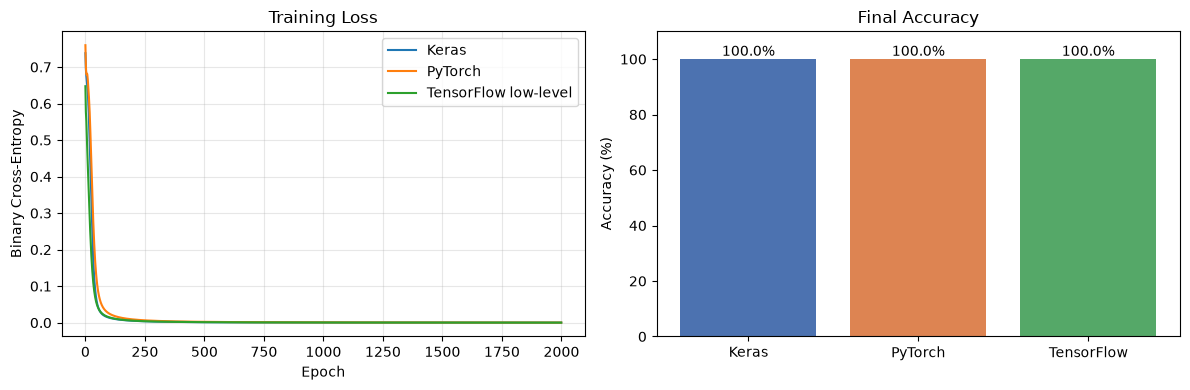

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(keras_history.history["loss"], label="Keras")
axes[0].plot(pytorch_losses, label="PyTorch")
axes[0].plot(tf_losses, label="TensorFlow low-level")
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Binary Cross-Entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

names = ["Keras", "PyTorch", "TensorFlow"]
accuracies = [keras_accuracy, pytorch_accuracy, tensorflow_accuracy]
bars = axes[1].bar(names, np.array(accuracies) * 100, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set(title="Final Accuracy", ylabel="Accuracy (%)", ylim=(0, 110))
axes[1].bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.show()

## 8. Decision Boundaries

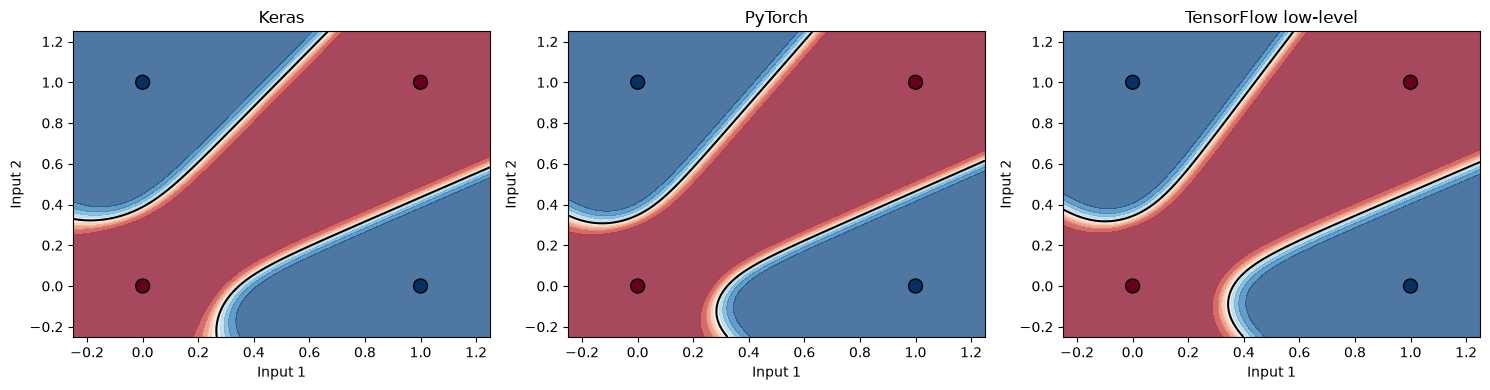

In [11]:
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(-0.25, 1.25, 200),
    np.linspace(-0.25, 1.25, 200),
)
grid = np.column_stack((grid_x1.ravel(), grid_x2.ravel())).astype(np.float32)

keras_grid = keras_model.predict(grid, verbose=0).reshape(grid_x1.shape)
with torch.no_grad():
    pytorch_grid = pytorch_model(torch.tensor(grid)).numpy().reshape(grid_x1.shape)
tensorflow_grid = tf_forward(tf.constant(grid)).numpy().reshape(grid_x1.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, surface, title in zip(
    axes,
    [keras_grid, pytorch_grid, tensorflow_grid],
    ["Keras", "PyTorch", "TensorFlow low-level"],
):
    ax.contourf(grid_x1, grid_x2, surface, levels=np.linspace(0, 1, 11), cmap="RdBu", alpha=0.75)
    ax.contour(grid_x1, grid_x2, surface, levels=[0.5], colors="black")
    ax.scatter(X[:, 0], X[:, 1], c=y.reshape(-1), cmap="RdBu", edgecolors="black", s=100)
    ax.set(title=title, xlabel="Input 1", ylabel="Input 2")
plt.tight_layout()
plt.show()

## Results

All three implementations correctly learned the XOR mapping and predicted `[0, 1, 1, 0]`.

| Implementation | Final Loss | Accuracy |
|---|---:|---:|
| Keras | 0.000139 | 100% |
| PyTorch | 0.000227 | 100% |
| TensorFlow low-level | 0.000142 | 100% |

The training curves show convergence toward a very small Binary Cross-Entropy loss. The decision-boundary plots show non-linear regions that correctly separate the two XOR classes.

## Viva Points

- XOR is not linearly separable; one straight line cannot separate its two classes.
- The hidden non-linear activation lets the network form multiple decision regions.
- Sigmoid maps the output to a probability between 0 and 1.
- Binary Cross-Entropy penalizes incorrect binary probabilities.
- Backpropagation updates weights using gradients of the loss.

## Conclusion

- A hidden layer with a non-linear activation enables an MLP to learn XOR.
- Keras, PyTorch, and low-level TensorFlow implement the same forward and backpropagation principles.
- In the recorded experiments, increasing the hidden layer from 2 to 4 neurons improved accuracy from 50% to 100%; additional epochs alone did not improve the 2-neuron configuration.
- Learning rate, activation, initialization, hidden capacity, and epochs jointly affect convergence.